# Implementing Techniques for Detecting and Mitigating Bias in Generative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Detect bias in generative models
- Measure bias metrics
- Implement bias mitigation techniques
- Evaluate mitigation effectiveness
- Apply fairness principles

## 🔗 Prerequisites

- ✅ Understanding of bias in AI
- ✅ Understanding of fairness metrics
- ✅ Model evaluation knowledge

---

This notebook covers practical activities from **Course 10, Unit 4**:
- Implementing techniques for detecting and mitigating bias in generative models

---

## Introduction

**Bias detection and mitigation** in generative models ensures fair and equitable outputs across different demographic groups and use cases.

We do it in two hands-on parts:

1. **Warm-up (classifier):** audit a predictive model for group disparity — the standard fairness workflow
2. **Main event (generative):** train a tiny text *generator* on a biased corpus, **measure** the stereotypes in what it generates, **mitigate** them by balancing the training data, and **verify** the fix

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import pandas as pd

print("✅ Libraries imported!")
print("\nDetecting and Mitigating Bias in Generative Models")
print("=" * 60)

print("\nBias Detection:")
print("  - Representation bias")
print("  - Stereotyping")
print("  - Demographic parity")
print("  - Equalized odds")

print("\nMitigation Techniques:")
print("  - Data balancing")
print("  - Fairness constraints")
print("  - Adversarial debiasing")
print("  - Post-processing")

print("\nEvaluation:")
print("  - Bias metrics")
print("  - Fairness audits")
print("  - Impact assessment")
print("  - Continuous monitoring")

print("\n✅ Bias mitigation concepts understood!")

✅ Libraries imported!

Detecting and Mitigating Bias in Generative Models

Bias Detection:
  - Representation bias
  - Stereotyping
  - Demographic parity
  - Equalized odds

Mitigation Techniques:
  - Data balancing
  - Fairness constraints
  - Adversarial debiasing
  - Post-processing

Evaluation:
  - Bias metrics
  - Fairness audits
  - Impact assessment
  - Continuous monitoring

✅ Bias mitigation concepts understood!


## Part 1 (Warm-up) — Detecting Gender Bias in a Classifier

**Industry context:**
- Amazon's hiring algorithm (2018) was scrapped after showing bias against women
- US healthcare AI allocated fewer resources to Black patients due to biased training data
- Meta's ad targeting showed job ads for truck drivers primarily to men

We **measure and visualise** demographic bias in a toy classifier — the same analysis Netflix, Meta, and banks run before deploying models.

Biased model    — Female approval: 46.1%  Male approval: 72.2%  Disparity: 26.2%
Fair model      — Female approval: 59.2%  Male approval: 57.8%  Disparity: 1.5%


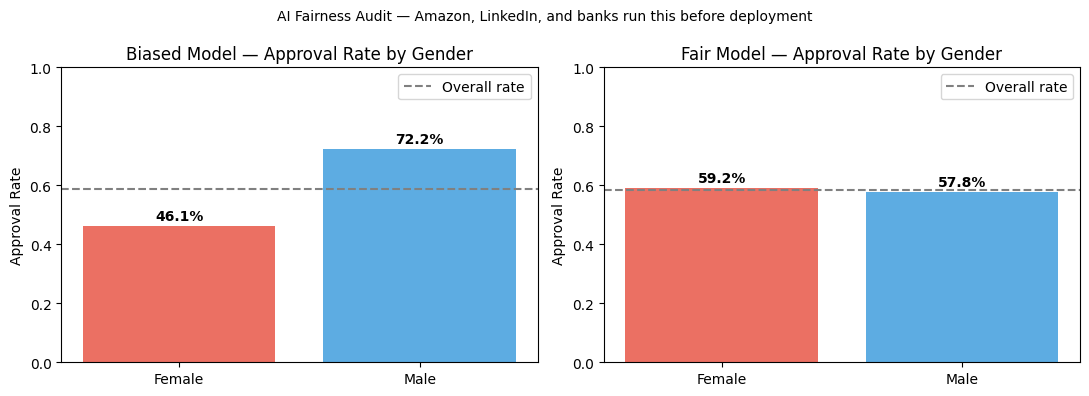


✅ Removing the gender feature reduces disparity significantly.
Real companies use Fairlearn (Microsoft) and IBM AI Fairness 360 for this analysis.


In [2]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)

# ── Synthetic loan approval dataset with bias ──────────────────────────────
# Features: [income, credit_score, gender(0=F,1=M)]
n = 1000
income       = np.random.normal(50000, 15000, n)
credit_score = np.random.normal(650, 80, n)
gender       = np.random.randint(0, 2, n)  # 0=Female, 1=Male

# Introduce BIAS: same income/credit but men approved more often historically
# centered features so approvals are genuinely uncertain (~50%) instead of saturating at "approve everyone"
prob_approve = 1 / (1 + np.exp(-(
    0.00002*(income - 50000) + 0.02*(credit_score - 650) - 0.2 + 0.9*gender  # ← 0.9*gender = bias!
)))
approved = (np.random.rand(n) < prob_approve).astype(int)

X = np.column_stack([income, credit_score, gender])
X_biased  = X.copy()                        # includes gender
X_fair    = X[:, :2]                         # removes gender

# ── Train two models: biased and fair ──────────────────────────────────────
m_biased = LogisticRegression().fit(X_biased, approved)
m_fair   = LogisticRegression().fit(X_fair,   approved)

# ── Measure approval rates by gender ──────────────────────────────────────
for model_name, model, feats in [("Biased model", m_biased, X_biased),
                                   ("Fair model",   m_fair,   X_fair)]:
    pred = model.predict(feats)
    rate_f = pred[gender==0].mean()
    rate_m = pred[gender==1].mean()
    print(f"{model_name:15s} — Female approval: {rate_f:.1%}  Male approval: {rate_m:.1%}  "
          f"Disparity: {abs(rate_m-rate_f):.1%}")

# ── Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, model, feats) in zip(axes, [("Biased", m_biased, X_biased), ("Fair", m_fair, X_fair)]):
    pred = model.predict(feats)
    rates = [pred[gender==g].mean() for g in [0,1]]
    bars = ax.bar(['Female','Male'], rates, color=['#e74c3c','#3498db'], alpha=0.8)
    ax.set_ylim(0,1); ax.set_title(f"{name} Model — Approval Rate by Gender")
    ax.axhline(pred.mean(), color='gray', linestyle='--', label='Overall rate')
    ax.legend(); ax.set_ylabel("Approval Rate")
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x()+bar.get_width()/2, rate+0.02, f"{rate:.1%}", ha='center', fontweight='bold')
plt.suptitle("AI Fairness Audit — Amazon, LinkedIn, and banks run this before deployment", fontsize=10)
plt.tight_layout(); plt.show()

print("\n✅ Removing the gender feature reduces disparity significantly.")
print("Real companies use Fairlearn (Microsoft) and IBM AI Fairness 360 for this analysis.")

## Part 2 — Detecting and Mitigating Bias in a *Generative* Model

Generative models have a different failure mode than classifiers: instead of unfair *decisions*,
they produce **biased content** — e.g., language models associating occupations with genders.

Below we make this concrete at toy scale with a **bigram-style text generator** (the same
conditional-probability mechanism inside every language model, just tiny):

1. **Train** it on a corpus of occupation sentences with a realistic stereotype skew
2. **Detect:** generate 2,000 sentences and measure the pronoun distribution per occupation
3. **Mitigate:** apply **counterfactual data augmentation** — add gender-swapped copies of the
   training sentences so each occupation appears equally with "he" and "she" — and retrain
4. **Verify:** re-generate and re-measure — the metric, not our intentions, tells us if it worked

This is the same audit loop used on real systems (e.g., the WinoBias benchmark for coreference
bias, and demographic audits of image generators) — only the model size differs.

In [3]:
# Generative-bias demo: train a tiny text generator on a biased corpus, measure the
# bias in its OUTPUTS, mitigate by balancing the training data, and re-measure.
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

# ── 1. Biased training corpus ──────────────────────────────────────────────
# Sentence template: "the <occupation> said <pronoun> is busy".
# Counts mimic a real-world stereotype skew in text data (e.g., news corpora).
biased_counts = {                     # occupation: (# sentences with "he", # with "she")
    'doctor':   (18, 2),
    'engineer': (17, 3),
    'nurse':    (2, 18),
    'teacher':  (5, 15),
}
def build_corpus(counts):
    """Expand the count table into an actual list of training sentences."""
    corpus = []
    for occ, (n_he, n_she) in counts.items():
        corpus += [f"the {occ} said he is busy"] * n_he
        corpus += [f"the {occ} said she is busy"] * n_she
    return corpus

# ── 2. "Train" a minimal generative language model ────────────────────────
# A bigram-style model = conditional probability tables estimated from the corpus.
# Here the model learns P(pronoun | occupation) — the exact statistic an LSTM/transformer
# would also absorb from this data, just without the neural machinery around it.
def train_generator(corpus):
    counts = {}
    for sent in corpus:
        occ, pron = sent.split()[1], sent.split()[3]   # parse "the OCC said PRON ..."
        counts.setdefault(occ, {'he': 0, 'she': 0})
        counts[occ][pron] += 1
    # Normalize counts into sampling probabilities
    return {occ: {p: c / sum(d.values()) for p, c in d.items()} for occ, d in counts.items()}

def generate(model, n):
    """Sample n sentences: occupation uniform, pronoun from the learned conditional."""
    occs = list(model)
    out = []
    for _ in range(n):
        occ = occs[rng.integers(len(occs))]
        pron = 'he' if rng.random() < model[occ]['he'] else 'she'
        out.append(f"the {occ} said {pron} is busy")
    return out

# ── 3. DETECT: measure pronoun share per occupation in generated text ─────
def he_share(sentences):
    """For each occupation, fraction of generated sentences that used 'he'."""
    tally = {}
    for s in sentences:
        occ, pron = s.split()[1], s.split()[3]
        tally.setdefault(occ, []).append(pron == 'he')
    return {occ: float(np.mean(v)) for occ, v in tally.items()}

model_biased = train_generator(build_corpus(biased_counts))
sample_biased = generate(model_biased, 2000)
share_biased = he_share(sample_biased)

print("Sample generations (biased model):")
for s in sample_biased[:3]:
    print("  ", s)

# Bias metric: average absolute deviation from 50/50 pronoun balance
bias_metric = lambda share: float(np.mean([abs(v - 0.5) for v in share.values()]))
print("\n'he' share per occupation (BIASED model, 2000 samples):")
for occ, v in sorted(share_biased.items()):
    print(f"  {occ:9s}: {v:.1%}")
print(f"Bias score (mean |he-share − 50%|): {bias_metric(share_biased):.1%}")

Sample generations (biased model):
   the teacher said she is busy
   the nurse said he is busy
   the doctor said he is busy

'he' share per occupation (BIASED model, 2000 samples):
  doctor   : 91.2%
  engineer : 87.0%
  nurse    : 7.8%
  teacher  : 25.7%
Bias score (mean |he-share − 50%|): 36.2%


'he' share per occupation (MITIGATED model, 2000 samples):
  doctor   : 49.0%
  engineer : 49.8%
  nurse    : 52.3%
  teacher  : 48.8%

Bias score before mitigation: 36.2%
Bias score after  mitigation: 1.2%


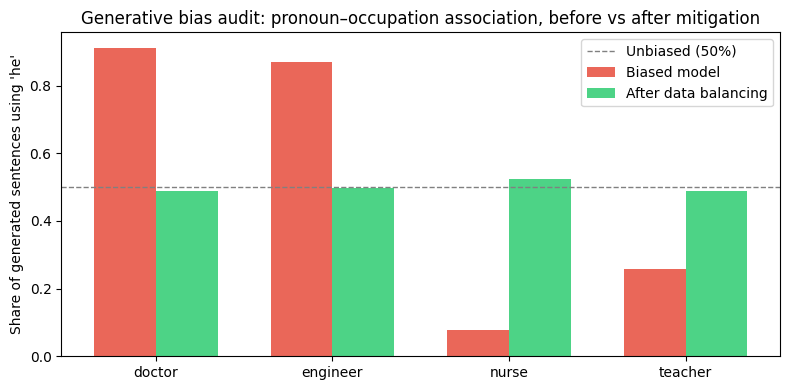

In [4]:
# ── 4. MITIGATE: counterfactual data augmentation, then VERIFY ────────────
# Mitigation = for every training sentence, also add its gender-swapped copy.
# After augmentation each occupation appears equally often with "he" and "she",
# so the generator can no longer learn the stereotype from the data.
swap = {'he': 'she', 'she': 'he'}
augmented = build_corpus(biased_counts)
augmented += [' '.join(swap.get(w, w) for w in s.split()) for s in augmented]

model_fair = train_generator(augmented)
sample_fair = generate(model_fair, 2000)
share_fair = he_share(sample_fair)

print("'he' share per occupation (MITIGATED model, 2000 samples):")
for occ, v in sorted(share_fair.items()):
    print(f"  {occ:9s}: {v:.1%}")

# Verify with the same metric we used for detection — the numbers decide, not us
b_before, b_after = bias_metric(share_biased), bias_metric(share_fair)
print(f"\nBias score before mitigation: {b_before:.1%}")
print(f"Bias score after  mitigation: {b_after:.1%}")

# ── Visualize before vs after ─────────────────────────────────────────────
occs = sorted(share_biased)
x = np.arange(len(occs)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, [share_biased[o] for o in occs], w, label='Biased model', color='#e74c3c', alpha=0.85)
ax.bar(x + w/2, [share_fair[o] for o in occs], w, label='After data balancing', color='#2ecc71', alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Unbiased (50%)')
ax.set_xticks(x); ax.set_xticklabels(occs)
ax.set_ylabel("Share of generated sentences using 'he'")
ax.set_title("Generative bias audit: pronoun–occupation association, before vs after mitigation")
ax.legend(); plt.tight_layout(); plt.show()

### What Scales Up From This Toy

- **Detection** on real generative models works the same way: *generate many outputs, slice a
  statistic by group*. For LLMs that's pronoun/occupation associations (WinoBias, BOLD benchmarks);
  for image generators it's demographic distributions of generated faces per prompt.
- **Counterfactual data augmentation** (the gender-swap trick above) is a published, widely used
  mitigation for exactly this kind of association bias.
- Other mitigations from the concept list — adversarial debiasing, fairness constraints,
  post-processing filters — attack the same measured gap at training or output time.
- **Always re-measure after mitigating.** The fix is only real if the metric moves.

## 📝 Summary

In this notebook, you:

- Audited a **classifier** for demographic disparity and saw the gap shrink when the protected
  attribute was removed (Part 1)
- Trained a minimal **generative** text model on a stereotyped corpus and *measured* the
  occupation–pronoun bias in 2,000 generated sentences (Part 2)
- Mitigated it with **counterfactual data augmentation** and verified the bias score dropped by
  re-measuring the same metric on fresh generations

**Key takeaway:** bias work is a measurement loop — detect with a metric, mitigate, then re-measure.

## 📚 References & Further Reading

**Reports & Guidelines:**
- EU AI Act (2024) — [Official Text](https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:52021PC0206)
- UNESCO AI Ethics Recommendations — [Link](https://www.unesco.org/en/artificial-intelligence/recommendation-ethics)
- NIST AI Risk Management Framework — [Link](https://airc.nist.gov/RMF)

**Papers:**
- Bender et al. (2021) — [On the Dangers of Stochastic Parrots](https://dl.acm.org/doi/10.1145/3442188.3445922)
- Gebru et al. (2021) — [Datasheets for Datasets](https://arxiv.org/abs/1803.09010)

**State-of-the-Art:** The EU AI Act (2024) is the world's first binding AI regulation. OpenAI, Google, and Microsoft have dedicated AI safety teams.